In [289]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

<h3><b><u>Task 1 — Data Loading & Exploration</u></b></h3>

In [290]:
#1.  Load the CSV file using Pandas
df = pd.read_csv("C:/Users/Yusuf Shaikh/Downloads/Housing.csv")

In [291]:
#2.  Display the first 10 rows
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [292]:
#3.   Check how many rows and columns are there
df.shape

(545, 13)

In [293]:
#4.   Identify which column is the target (Price) and which are features
target = df['price']
print("Target Column")
print(target.head(5))

Target Column
0    13300000
1    12250000
2    12250000
3    12215000
4    11410000
Name: price, dtype: int64


In [294]:
features = df.drop(columns = ['price'])
print("Featured Columns")
print(features.head(5))

Featured Columns
   area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  7420         4          2        3      yes        no       no   
1  8960         4          4        4      yes        no       no   
2  9960         3          2        2      yes        no      yes   
3  7500         4          2        2      yes        no      yes   
4  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [295]:
#5.   Check for missing values in each column
count = df.isnull().sum()
count

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

<h3><b><u>Task 2 — Data Cleaning</u></b></h3>

In [296]:
#1.  Handle missing values (fill or drop, whichever fits the column)
assert count.sum() == 0  #Assert block is to prove the dataset is clean
print("\nNo Missing values")
# df.dropna().head()
# df = df.fillna(0)
# df.head()


No Missing values


In [297]:
#2.  Remove duplicate rows, if any
print(df.duplicated().sum())

0


In [298]:
#3.   Convert any categorical columns (e.g., yes/no fields) into numeric form using one-hot encoding
# if in data set there any categorical columns like yes/no , male/female like that so
# machine learning fails to understand tthat so it converts it into numerical form using one hot encoding.
# pd.get_dummies(df, columns=['mainroad'],['guestroom'],['basement'],['hotwaterheating'],['airconditioning'],['prefarea'])
# print(df.columns.tolist())
df = pd.get_dummies(df,columns=['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea','furnishingstatus'])

In [299]:
print(df.select_dtypes(include='object').columns)

Index([], dtype='object')


In [300]:
df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_no,mainroad_yes,guestroom_no,guestroom_yes,...,basement_yes,hotwaterheating_no,hotwaterheating_yes,airconditioning_no,airconditioning_yes,prefarea_no,prefarea_yes,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,False,True,True,False,...,False,True,False,False,True,False,True,True,False,False
1,12250000,8960,4,4,4,3,False,True,True,False,...,False,True,False,False,True,True,False,True,False,False
2,12250000,9960,3,2,2,2,False,True,True,False,...,True,True,False,True,False,False,True,False,True,False
3,12215000,7500,4,2,2,3,False,True,True,False,...,True,True,False,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,False,True,False,True,...,True,True,False,False,True,True,False,True,False,False


In [301]:
print(df.select_dtypes(include='object').columns) #Python me strings/text columns ka datatype usually (object) hota hai.so it will select object columns if there any  

Index([], dtype='object')


In [302]:
#4.    Keep only the columns that are meaningful for predicting price
Numeric_column = df.corr(numeric_only=True)['price'].abs()
meaningful_features = Numeric_column[Numeric_column > 0.1].index
df_meaningful = df[meaningful_features]
print(df_meaningful.columns.tolist())

['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'mainroad_no', 'mainroad_yes', 'guestroom_no', 'guestroom_yes', 'basement_no', 'basement_yes', 'airconditioning_no', 'airconditioning_yes', 'prefarea_no', 'prefarea_yes', 'furnishingstatus_furnished', 'furnishingstatus_unfurnished']


<h3><b><u>Task 3 — Model Building</u></b></h3>

In [303]:
#1.   Split the data into training and test sets (80/20)
X = df.drop(['price'], axis = 1) # feature , axis =1 to remove all (column) not (row) price column will remve except all colummn 
y = df['price']  #target 

In [304]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=42) # (0.20)means 20% test data and # (random_state=42 ) Same split every time
print("X_train shape: ", X_train.shape) # 80% X_train (436 rows) + y_train (436 prices) outoff 545 rows
print("X_test shape: ", X_test.shape) # 20% X_test (109 rows) + y_test (109 prices) outoff 545 rows
print("y_train shape: ", y_train.shape)
print("y_test shape: ", y_test.shape)

X_train shape:  (436, 20)
X_test shape:  (109, 20)
y_train shape:  (436,)
y_test shape:  (109,)


In [305]:
#2.  Train a Linear Regression model to predict house price
## Linear Regression is a supervised machine learning algorithm used to predict continuous values.
model = LinearRegression() # formula - y=b0+b1x1+b2x2+b3x3+⋯+bnxn
model.fit(X_train, y_train) # X_train = Features y_train = Target(price) -trained the model using this 

LinearRegression()

In [306]:
y_predict = model.predict(X_test) # Predict  (generated predictions using)
print(y_predict[:10]) #ex:- area-1000,bedrooms-3,bathrooms-2(y=b0+b1x1+b2x2+b3x3+⋯+bnxn)
#Intercept = 500000, area coefficient = 300, bedrooms coefficient = 200000, bathrooms coefficient = 150000
#Price=500000+(300×1000)+(200000×3)+(150000×2) = Predicted Price = ₹17,00,000

[5164653.90033967 7224722.29802167 3109863.24240338 4612075.32722559
 3294646.25725955 3532275.09556559 5611774.56836476 6368145.98732718
 2722856.95689985 2629405.61585782]


In [307]:
#3.  Evaluate it using MAE, RMSE, and R² Score
# Assuming 'y_test' is your actual target values and 'y_pred' is what your model predicted
mae = mean_absolute_error(y_test, y_predict) # mean_absolute_error
print(f"Mean Absolute Error: {mae:,.2f}") # mae Tells you the average size of your mistakes

mse = mean_squared_error(y_test, y_predict) # mean_squared_error

rmse = np.sqrt(mse) # RMSE is the square root of mean_squared_error(mse)
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}") #RMSE is significantly higher than your MAE, it means your model is making a few very large errors on certain properties.

r2 = r2_score(y_test, y_predict) #Tells you how good your model is compared to a simple average line
print(f"R² Score (Coefficient of Det.): {r2:.4f}")

Mean Absolute Error: 970,043.40
Root Mean Squared Error (RMSE): 1,324,506.96
R² Score (Coefficient of Det.): 0.6529


In [308]:
# 4.   Train a second model — Random Forest Regressor — and compare its performance to the Linear Regression model
linear_model = LinearRegression() # Initialize both models
random_model = RandomForestRegressor(n_estimators=100, random_state=42) 


In [309]:
linear_model.fit(X_train, y_train)  #Train (fit) both models
random_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [310]:
y_predict_linear = linear_model.predict(X_test) #Generate predictions on the test dataset
y_predict_random = random_model.predict(X_test) 

In [311]:
mae_linear = mean_absolute_error(y_test, y_predict_linear) #Calculate metrics for Linear Regression
rmse_linear = np.sqrt(mean_squared_error(y_test, y_predict_linear))
r2_linear = r2_score(y_test, y_predict_linear)

In [312]:
mae_random = mean_absolute_error(y_test, y_predict_random) #Calculate metrics for Random Forest
rmse_random = np.sqrt(mean_squared_error(y_test, y_predict_random))
r2_random = r2_score(y_test, y_predict_random)

In [313]:
 #Create a clean comparison DataFrame
comparison_dict = {"Metric": ["MAE", "RMSE", "R² Score"], 
                   "Linear Regression": [mae_linear, rmse_linear, r2_linear],
                   "Random Forest": [mae_random, rmse_random, r2_random]}
comparison_df = pd.DataFrame(comparison_dict)

In [314]:
# Format numerical outputs for easy reading
print("Model Performance Comparison")
print(comparison_df.to_string(index=False, formatters={
    "Linear Regression": lambda x: f"{x:,.2f}" if x > 1 else f"{x:.4f}",
    "Random Forest": lambda x: f"{x:,.2f}" if x > 1 else f"{x:.4f}"
}))

Model Performance Comparison
  Metric Linear Regression Random Forest
     MAE        970,043.40  1,025,824.38
    RMSE      1,324,506.96  1,404,074.82
R² Score            0.6529        0.6100


<h3><b><u>Task 4 — Visualization (Minimum 3 charts)</u></b></h3>

C:\Users\Yusuf Shaikh\AppData\Local\Temp\ipykernel_45996\2488999889.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([f'{x:,.0f}' for x in current_values])


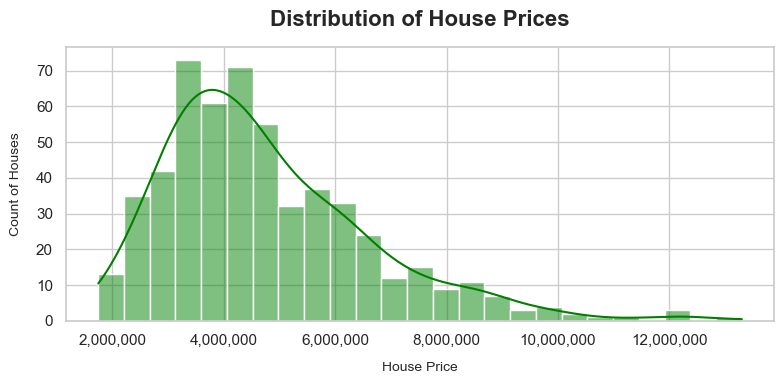

In [337]:
#1. Chart 1: Histogram showing the distribution of house prices
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 4))

sns.histplot(data=df,x='price',bins=25,kde=True,color='green')

plt.title('Distribution of House Prices', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('House Price', fontsize=10, labelpad=10)
plt.ylabel('Count of Houses', fontsize=10, labelpad=10)

current_values = plt.gca().get_xticks()
plt.gca().set_xticklabels([f'{x:,.0f}' for x in current_values])

plt.tight_layout()

# Save image
plt.savefig('house_price_distribution.png', dpi=300, bbox_inches='tight')

plt.show()

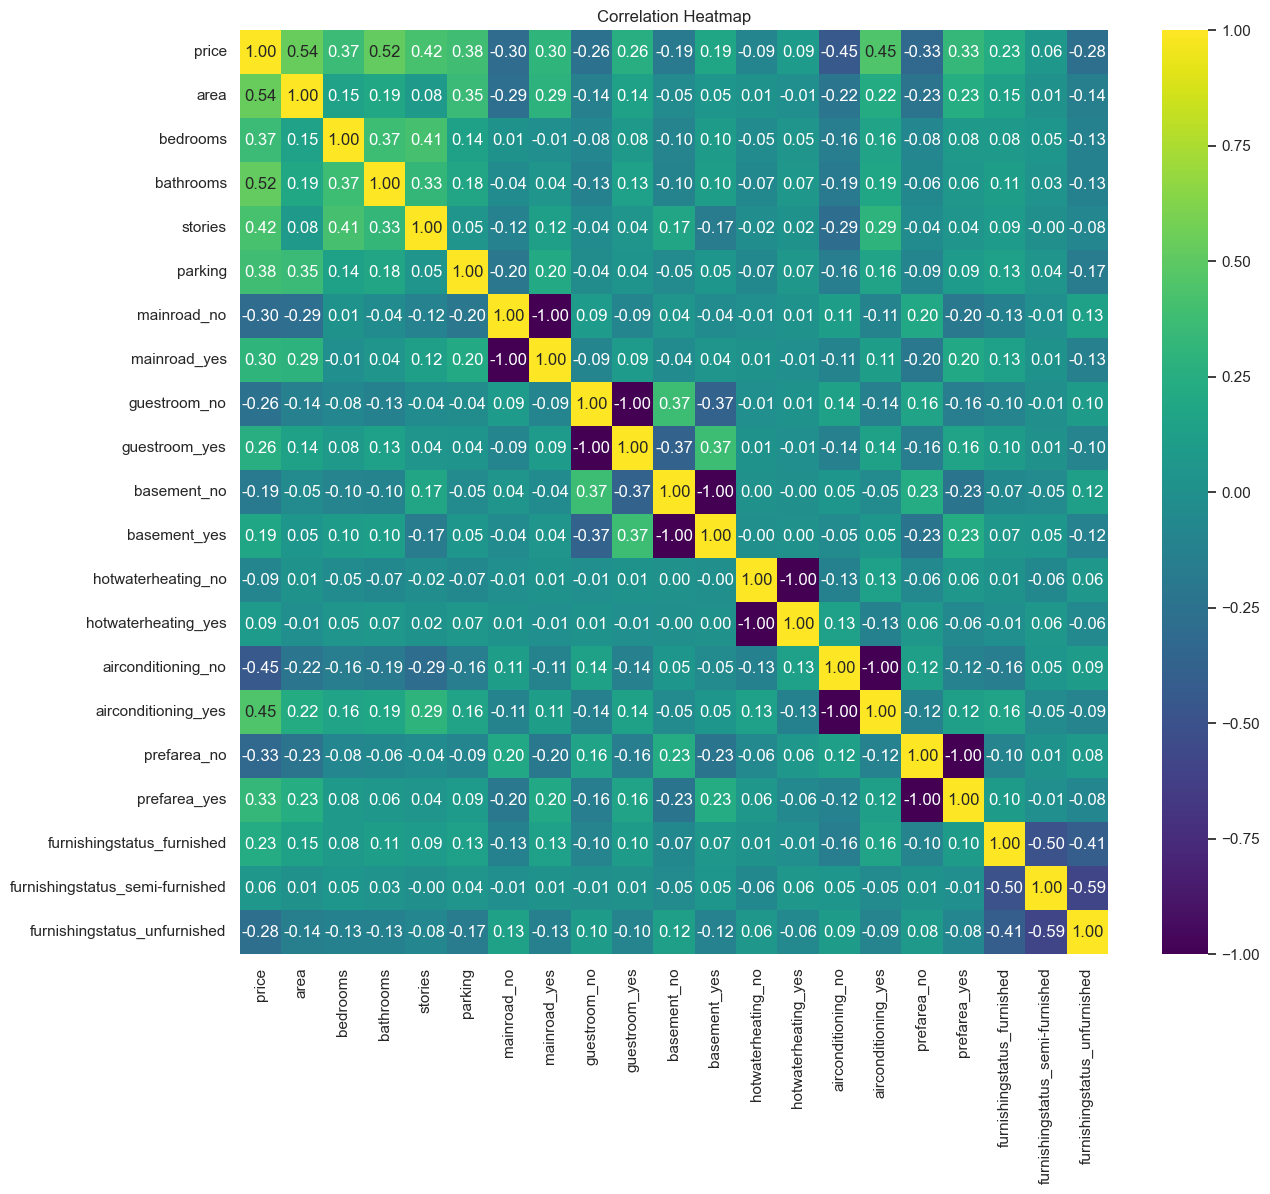

In [340]:
# 2.   Chart 2: Correlation heatmap showing which features relate most strongly to price
plt.figure(figsize=(14, 12))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='viridis',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

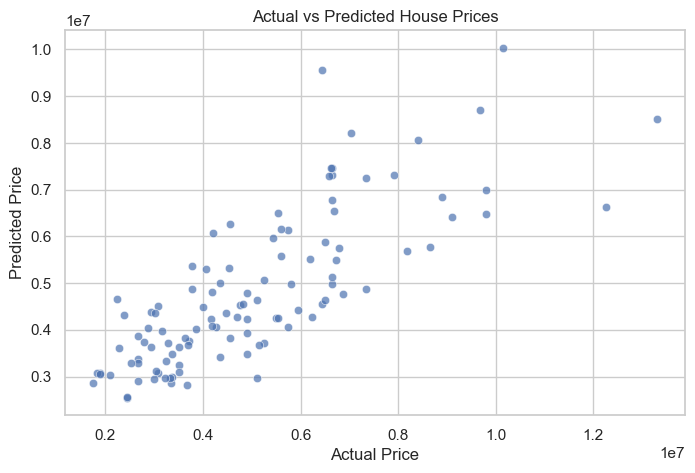

In [341]:
 #3.  Chart 3: A chart of your own choice — be creative! (e.g., actual vs. predicted price scatter plot, price vs. area scatter plot, etc.)
plt.figure(figsize=(8, 5))

sns.scatterplot(x=y_test, y=y_predict_random, alpha=0.7)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.savefig("actual vs predicted price.png", dpi=300, bbox_inches="tight")

plt.show()

<h3><b><u>Task 5 — Insights & Summary</u></b></h3>

<p> Which features influence house price the most?</p>
<p><b>According to the heatmap, area and bathrooms affect house prices the most. Houses with bigger areas and more bathrooms usually have higher prices.</b></p>

<p>How accurate was your model (in plain terms)?</p>
<p><b>My model performed fairly well with an R² score of 0.65. This means it was able to predict house prices reasonably close to the actual values most of the time.</b></p>

<p>What surprised you in the data?</p>
<p><b>I was surprised to see that air conditioning and preferred area had a noticeable impact on house prices. I expected house size to matter, but not these features as much</b></p>

<p>One recommendation for a real estate business based on your findings.</p>
<p><b>I would recommend focusing on houses with larger areas and better amenities because these features seem to increase property prices the most.</b></p>